In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# ── Configuration ─────────────────────────────────────────────────────────────
INPUT_CSV  = "/home/bri/pymol/data/predictions/predictions_3ab.csv" 
OUTPUT_DIR = Path("pipeline_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

KEEP_INTERFACES = {"A,C", "B,C"}
palette = {"binder": "#2196F3", "ala_scan": "#FF5722"}

In [ ]:
# ── Step 1: Load & Filter ─────────────────────────────────────────────────────

df = pd.read_csv(INPUT_CSV)
df = df[df["interface"].str.strip().isin(KEEP_INTERFACES)].copy()
print(f"Loaded {len(df)} rows. Interfaces: {df['interface'].unique()}")


STEP 1 — Load & Filter
Loaded 70 rows. Interfaces: <StringArray>
['A,C', 'B,C']
Length: 2, dtype: str


In [ ]:
# ── Step 2: Parse Labels ─────────────────────────────────────────────

# Use ground truth column for grouping
df['group'] = df['binding'].map({True: 'binder', False: 'ala_scan'})

# Base name extraction: removes '_A_K110A' OR '_all_A' from sample name
df['base'] = df['sample'].str.replace(r'(_[A-Z]_[A-Z]\d+[A-Z]$|_all_[A-Z]$)', '', regex=True)

# Also extract mutation string for heatmaps
df['mutation'] = df.apply(lambda r: r['sample'].replace(r['base']+'_', '') if not r['binding'] else 'WT', axis=1)
df['mut_chain'] = df['sample'].str.extract(r'_([A-Z])_[A-Z]\d+[A-Z]$|_all_([A-Z])$').bfill(axis=1)[0]

print(df["group"].value_counts().to_string())
print(f"Found {df['base'].nunique()} base structures and {df['mutation'].nunique()} mutations.")



STEP 2 — Parse Labels & Bases
group
ala_scan    64
binder       6
Found 3 base structures and 24 mutations.


In [6]:
# ── Step 4: Direction Alignment ───────────────────────────────────────────────
metadata = {'sample', 'binding', 'interface', 'base', 'group', 'mutation', 'mut_chain'}
score_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in metadata and "path" not in c]

aligned_df = df.copy()
for col in score_cols:
    # Match longest suffix in our directions dict
    matches = [k for k in METRIC_DIRECTIONS if col.endswith(k)]
    if matches:
        direction = METRIC_DIRECTIONS[max(matches, key=len)]
        aligned_df[col] *= direction

print(aligned_df.head())

                 sample  binding interface   af3_pae  af3_plddt  \
1  5ig7_abc_cut_B_G114A    False       A,C -2.436673  95.869087   
2  5ig7_abc_cut_B_G114A    False       B,C -2.436673  95.869087   
4  5ig7_abc_cut_A_K110A    False       A,C -2.806122  94.950463   
5  5ig7_abc_cut_A_K110A    False       B,C -2.806122  94.950463   
7  5ijk_acx_cut_A_I112A    False       A,C -2.957804  94.094014   

   af3_interface_dG  af3_interface_dG_SASA_ratio  af3_ipae  af3_iplddt  \
1            -24.31                        -3.01 -2.137500   95.580074   
2             -0.09                        -0.01 -1.631250   95.483511   
4            -15.92                        -2.31 -2.525000   92.630260   
5            -17.58                        -2.37 -1.915000   94.081369   
7           -102.47                       -22.93 -3.628571   75.386758   

   af3_ipsae  ...  boltz_template_plddt  boltz_template_iplddt  \
1   0.803864  ...              0.986487               0.986081   
2   0.816920  ...   

In [7]:
# ── Step 5: ΔΔScore Sanity Check ──────────────────────────────────────────────
wt_df = df[df["group"] == "binder"].set_index(["base", "interface"])[score_cols]
mut_df = df[df["group"] == "ala_scan"].copy()
mut_df = mut_df.join(wt_df, on=['base', 'interface'], rsuffix='_WT')

delta_rows = []
for _, row in mut_df.iterrows():
    if pd.isna(row[f"{score_cols[0]}_WT"]): continue
    d = {c: row[c] - row[f"{c}_WT"] for c in score_cols}
    d.update({k: row[k] for k in ["sample", "base", "interface", "mutation", "mut_chain"]})
    d["expected_affected"] = str(row["mut_chain"]) in str(row["interface"])
    delta_rows.append(d)

df_delta = pd.DataFrame(delta_rows)
if not df_delta.empty:
    df_delta.to_csv(OUTPUT_DIR / "scores_delta.csv", index=False)
    print(f"Calculated {len(df_delta)} delta scores.")



Calculated 64 delta scores.


In [8]:
# ── Step 6: EDA Plots (Distributions & Separability) ──────────────────────────

# Top 12 metrics for plotting
KEY_METRICS = [c for c in score_cols if any(k in c for k in ["iptm", "plddt", "pae", "dG", "ipsae"])][:12]

for iface in KEEP_INTERFACES:
    sub = aligned_df[aligned_df["interface"] == iface]
    if sub.empty: continue
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    for i, col in enumerate(KEY_METRICS):
        ax = axes.flatten()[i]
        for grp, color in palette.items():
            vals = sub[sub["group"] == grp][col].dropna()
            if not vals.empty: sns.kdeplot(vals, ax=ax, label=grp, color=color, fill=True)
        ax.set_title(col, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"distributions_{iface.replace(',', '')}.png")
    plt.close()


Generating distributions for 48 metrics...


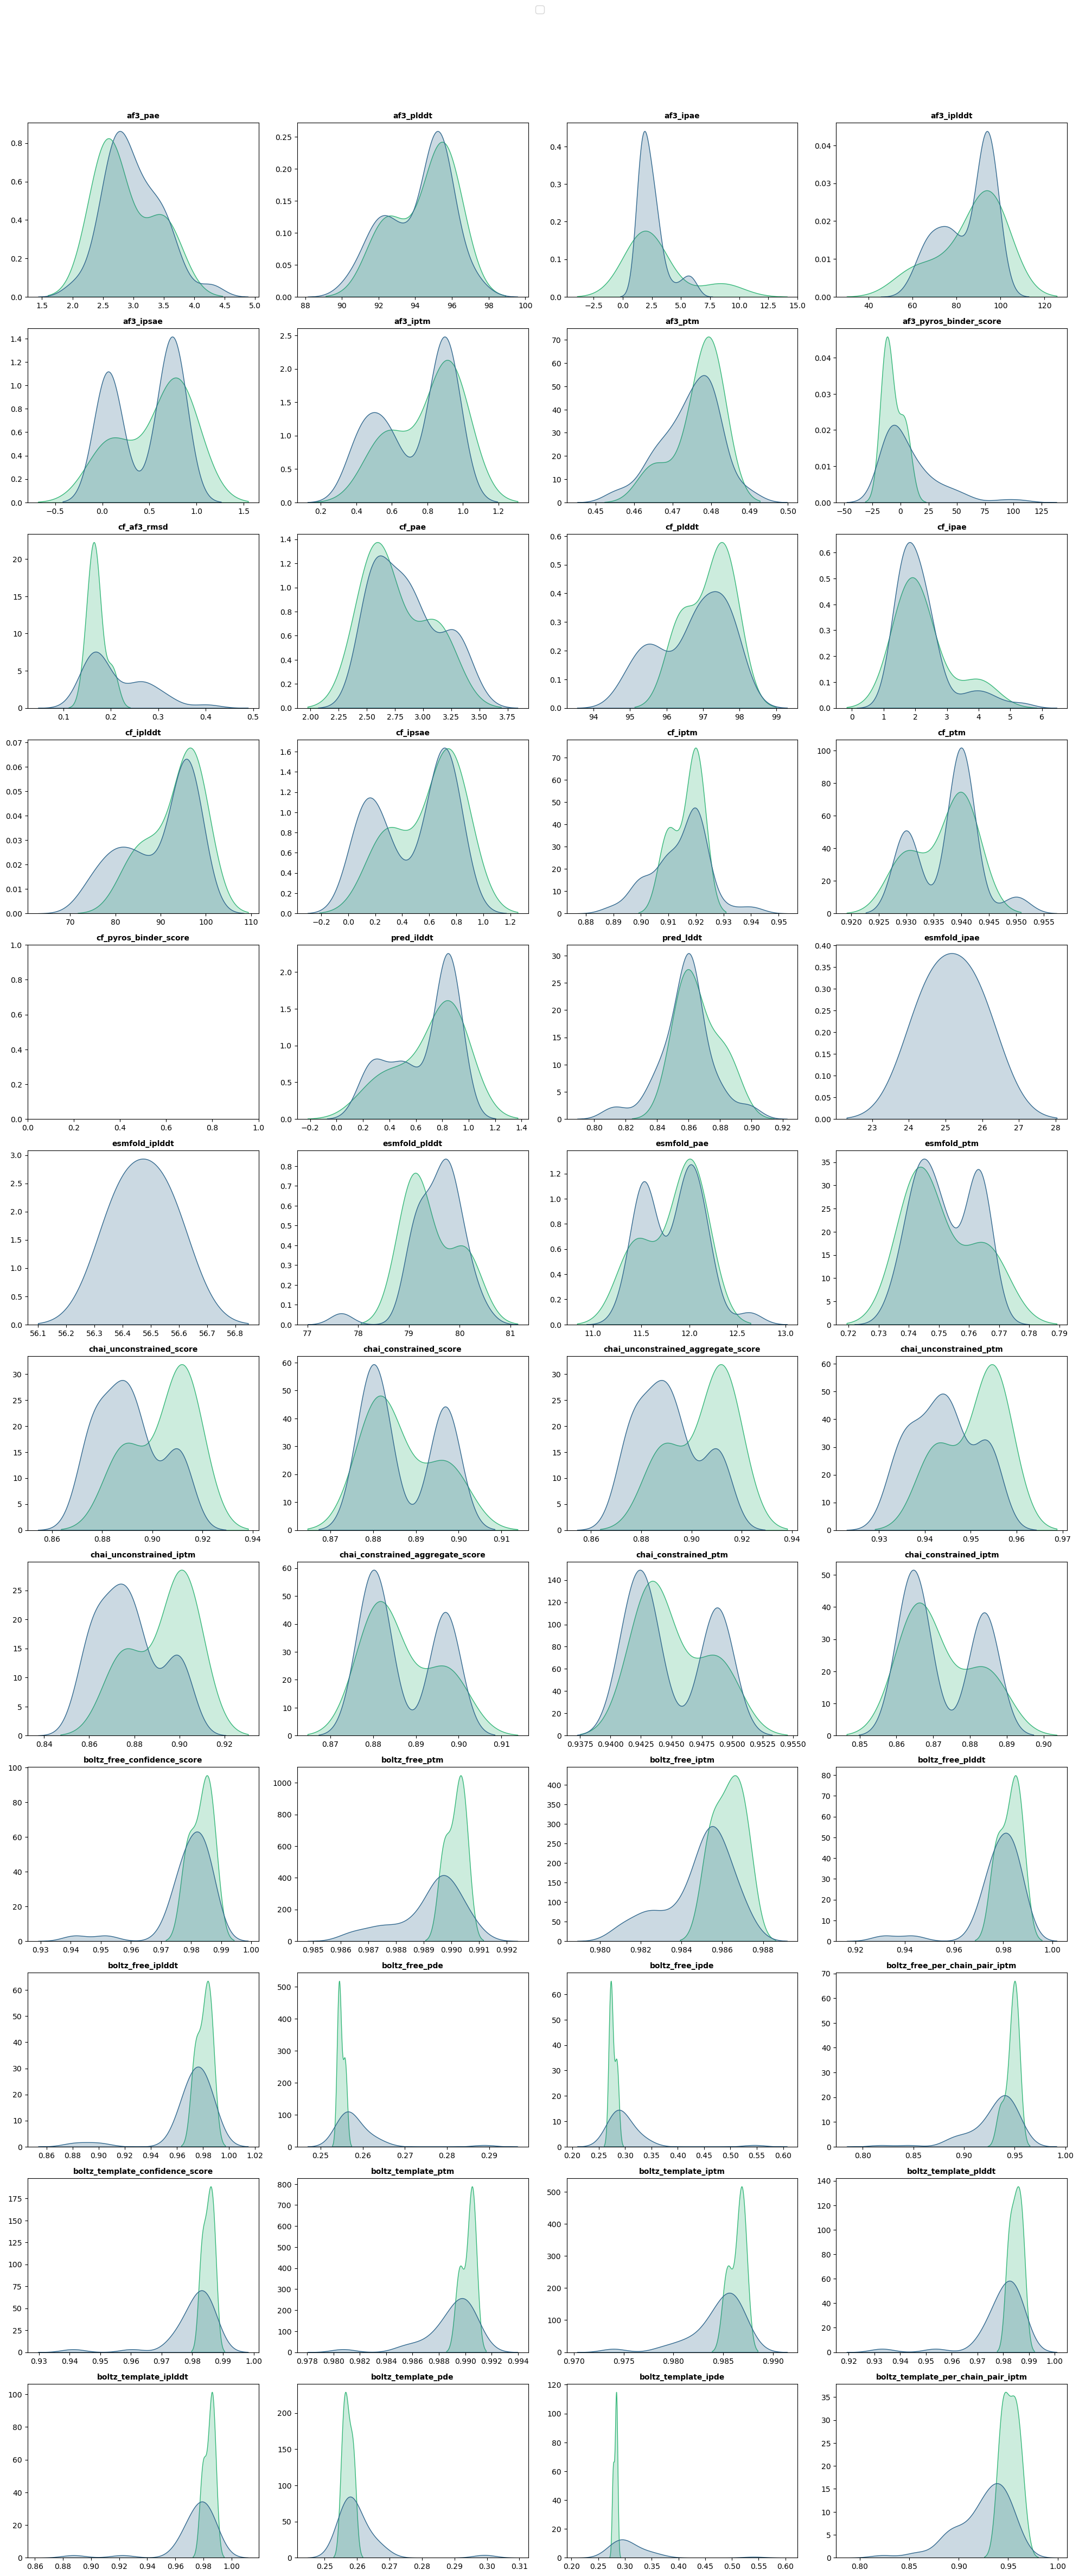

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Automatically identify numeric columns, excluding metadata/rankings
# We want to skip 'rank', 'sample', etc., but keep the actual scores
exclude_keywords = ['sample', 'rank', 'path', 'interface', 'group', 'base', 'mutation', 'mut_chain']
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns 
    if not any(k in c.lower() for k in exclude_keywords)
]

# 2. Calculate grid dimensions (4 columns wide)
n_metrics = len(numeric_cols)
n_cols = 4
n_rows = (n_metrics // n_cols) + (1 if n_metrics % n_cols > 0 else 0)

# 3. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

print(f"Generating distributions for {n_metrics} metrics...")

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Plot Kernel Density Estimate for Binders vs Non-Binders
    # Assuming 'binding' column contains 0/1 or True/False
    sns.kdeplot(data=df, x=col, hue='binding', fill=True, ax=ax, common_norm=False, palette='viridis')
    
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Clean up: remove legend from individual plots to save space
    if ax.get_legend():
        ax.get_legend().remove()

# Add a single global legend at the top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 1.02))

# 4. Final layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(OUTPUT_DIR / "all_scores_distribution_overview.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:

# ── Step 7: Final Metric Evaluation (ROC/PR) ──────────────────────────────────

eval_summary = []
for iface in list(KEEP_INTERFACES) + ["all"]:
    sub = aligned_df if iface == "all" else aligned_df[aligned_df["interface"] == iface]
    if sub['group'].nunique() < 2: continue
    
    y_true = sub['binding'].astype(int)
    for col in score_cols:
        scores = sub[col]
        if scores.isna().any(): continue
        
        roc = roc_auc_score(y_true, scores)
        pr = average_precision_score(y_true, scores)
        
        eval_summary.append({'interface': iface, 'metric': col, 'roc_auc': roc, 'pr_auc': pr})

res_df = pd.DataFrame(eval_summary).sort_values(['interface', 'pr_auc'], ascending=[True, False])
res_df.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)

# Final plotting: Side-by-side PR/ROC for each interface
for iface in res_df['interface'].unique():
    top = res_df[res_df['interface'] == iface].head(20)[::-1]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    ax1.barh(top['metric'], top['pr_auc'], color='#1976D2')
    ax1.set_title(f"PR-AUC ({iface})")
    ax2.barh(top['metric'], top['roc_auc'], color='#388E3C')
    ax2.set_title(f"ROC-AUC ({iface})")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"final_metrics_{iface}.png")
    plt.close()

print(f"DONE. Detailed results in {OUTPUT_DIR}")

DONE. Detailed results in pipeline_analysis
